# PitWall Intelligence — BVI Computation Walkthrough
**Student:** Dharmik Champaneri | **ID:** 20327984

This notebook walks through the Brand Value Index (BVI) formula step-by-step:
- Performance dimension (40%)
- Consistency dimension (30%)
- Exposure dimension (30%)
- Composite BVI and tier classification
- Season-by-season results and validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

RAW = Path('../data/raw')
OUT = Path('../data/processed')

## 1. Load and prepare data

In [4]:
RAW = Path('/content/') # Temporarily redefine RAW to point to the correct data directory

races        = pd.read_csv(RAW / 'races.csv')
results      = pd.read_csv(RAW / 'results.csv')
constructors = pd.read_csv(RAW / 'constructors.csv')
status       = pd.read_csv(RAW / 'status.csv')

SEASONS = list(range(2018, 2024))
DNF_KEYWORDS = [
    'Accident','Collision','Engine','Gearbox','Hydraulics','Mechanical',
    'Retired','Suspension','Brakes','Electrical','Wheel','Transmission',
    'Differential','Oil','Fire','Throttle','Steering','Clutch','Puncture',
]
dnf_ids = set(
    status[status['status'].str.contains('|'.join(DNF_KEYWORDS), case=False, na=False)]['statusId']
)

season_races = races[races['year'].isin(SEASONS)][['raceId','year']]
merged = (
    results
    .merge(season_races, on='raceId')
    .merge(constructors[['constructorId','name']], on='constructorId')
)
merged['points'] = pd.to_numeric(merged['points'], errors='coerce').fillna(0)
print(f'Analysis rows: {len(merged):,}')

Analysis rows: 2,500


## 2. Helper: min-max normalisation

In [5]:
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)

print('minmax([0,50,100]) =>', minmax(pd.Series([0, 50, 100])).tolist())

minmax([0,50,100]) => [0.0, 0.5, 1.0]


## 3. Aggregate raw stats per constructor × season

In [6]:
raw_rows = []
for season, s_grp in merged.groupby('year'):
    for (cid, cname), g in s_grp.groupby(['constructorId','name']):
        entries = len(g)
        total_points = float(g['points'].sum())
        wins         = int((g['positionOrder'] == 1).sum())
        podiums      = int((g['positionOrder'] <= 3).sum())
        podium_rate  = podiums / entries if entries else 0.0
        dnf_count    = int(g['statusId'].isin(dnf_ids).sum())
        dnf_rate     = dnf_count / entries if entries else 0.0
        pts_fin_rate = float((g['points'] > 0).sum()) / entries if entries else 0.0
        valid        = g[g['grid'] > 0]
        avg_delta    = float((valid['grid'] - valid['positionOrder']).mean()) if len(valid) else 0.0
        broadcast    = float(podiums * 1.0 + wins * 2.0)

        raw_rows.append({
            'constructor_id': cid, 'constructor': cname, 'season': int(season),
            'total_points': total_points, 'wins': wins, 'podiums': podiums,
            'entries': entries, 'dnf_rate': dnf_rate,
            'pts_finish_rate': pts_fin_rate, 'avg_delta': avg_delta,
            'broadcast_proxy': broadcast, 'podium_rate': podium_rate,
        })

df = pd.DataFrame(raw_rows)
print(df.head())

   constructor_id constructor  season  total_points  wins  podiums  entries  \
0               1     McLaren    2018          62.0     0        0       42   
1               3    Williams    2018           7.0     0        0       42   
2               4     Renault    2018         122.0     0        0       42   
3               5  Toro Rosso    2018          33.0     0        0       42   
4               6     Ferrari    2018         571.0     6       24       42   

   dnf_rate  pts_finish_rate  avg_delta  broadcast_proxy  podium_rate  
0  0.238095         0.309524   1.642857              0.0     0.000000  
1  0.142857         0.071429   1.428571              0.0     0.000000  
2  0.190476         0.571429  -0.428571              0.0     0.000000  
3  0.261905         0.190476   0.658537              0.0     0.000000  
4  0.071429         0.880952  -1.619048             36.0     0.571429  


## 4. Compute BVI dimensions and composite score

In [8]:
bvi_rows = []
for season, g in df.groupby('season'):
    d = g.copy().reset_index(drop=True)

    # Performance (40%)
    perf = (
        minmax(d['total_points'])         * 0.50
        + minmax(d['podium_rate'])        * 0.30
        + minmax(d['wins'].astype(float)) * 0.20
    ) * 100

    # Consistency (30%)
    cons = (
        minmax(1 - d['dnf_rate'])         * 0.40
        + minmax(d['pts_finish_rate'])    * 0.40
        + minmax(d['avg_delta'])          * 0.20
    ) * 100

    # Exposure (30%)
    expo = (
        minmax(d['broadcast_proxy'])           * 0.70
        + minmax(d['podiums'].astype(float))   * 0.30
    ) * 100

    d['perf_score'] = perf.round(2)
    d['cons_score'] = cons.round(2)
    d['expo_score'] = expo.round(2)
    d['bvi']  = (d['perf_score'] * 0.40 + d['cons_score'] * 0.30 + d['expo_score'] * 0.30).round(2)
    d['tier'] = d['bvi'].apply(lambda x: 1 if x >= 75 else (2 if x >= 50 else 3))
    bvi_rows.append(d)

bvi = pd.concat(bvi_rows, ignore_index=True)

OUT.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist
bvi.to_csv(OUT / 'bvi_scores.csv', index=False)
print('BVI scores saved.')
bvi[bvi['season'] == 2023].sort_values('bvi', ascending=False)[['constructor','bvi','tier','perf_score','cons_score','expo_score']]

BVI scores saved.


,constructor,bvi,tier,perf_score,cons_score,expo_score
53,Red Bull,100.00,1,100.00,100.00,100.00
56,Mercedes,38.75,3,31.37,71.57,15.78
55,Aston Martin,37.53,3,24.45,76.73,15.78
52,Ferrari,36.18,3,32.62,57.43,19.69
50,McLaren,35.52,3,25.45,66.70,17.75
54,Alfa Romeo,13.71,3,0.45,45.11,0.00
59,Alpine F1 Team,13.47,3,8.47,29.67,3.94
58,AlphaTauri,13.16,3,0.83,42.75,0.00
57,Haas F1 Team,6.05,3,0.00,20.16,0.00
51,Williams,4.99,3,1.09,15.17,0.00


## 5. BVI distribution analysis

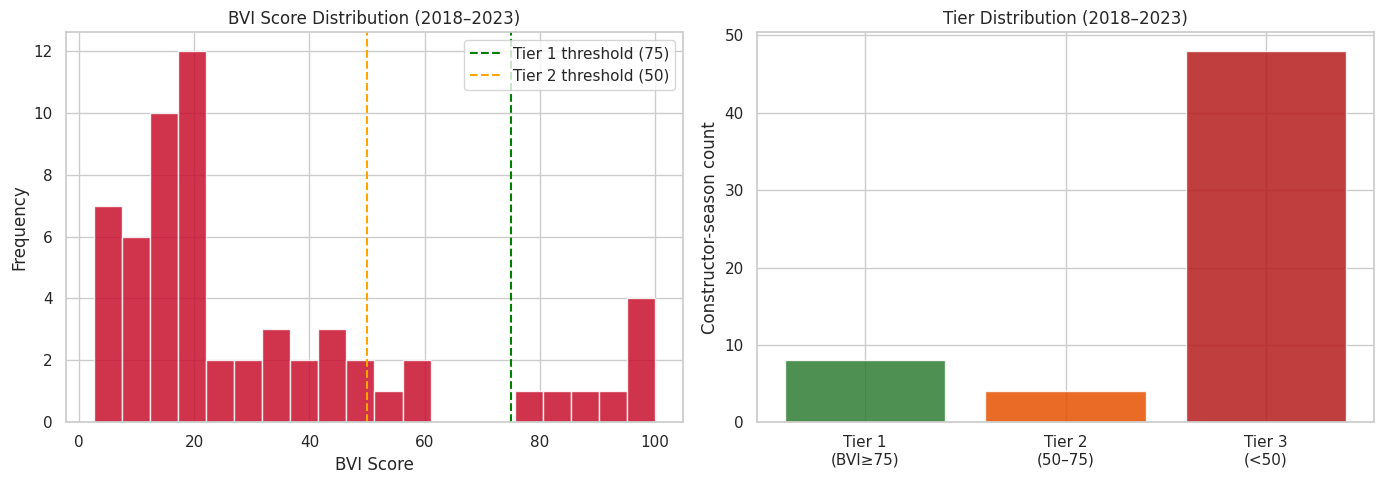

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(bvi['bvi'], bins=20, color='#C8102E', edgecolor='white', alpha=0.85)
axes[0].axvline(75, color='green', linestyle='--', label='Tier 1 threshold (75)')
axes[0].axvline(50, color='orange', linestyle='--', label='Tier 2 threshold (50)')
axes[0].set_xlabel('BVI Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BVI Score Distribution (2018–2023)')
axes[0].legend()

# Tier breakdown
tier_counts = bvi['tier'].value_counts().sort_index()
axes[1].bar(
    ['Tier 1\n(BVI≥75)', 'Tier 2\n(50–75)', 'Tier 3\n(<50)'],
    tier_counts.values,
    color=['#2e7d32', '#e65100', '#b71c1c'], alpha=0.85
)
axes[1].set_ylabel('Constructor-season count')
axes[1].set_title('Tier Distribution (2018–2023)')

plt.tight_layout()
plt.savefig(OUT / 'bvi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. BVI trend — top constructors over time

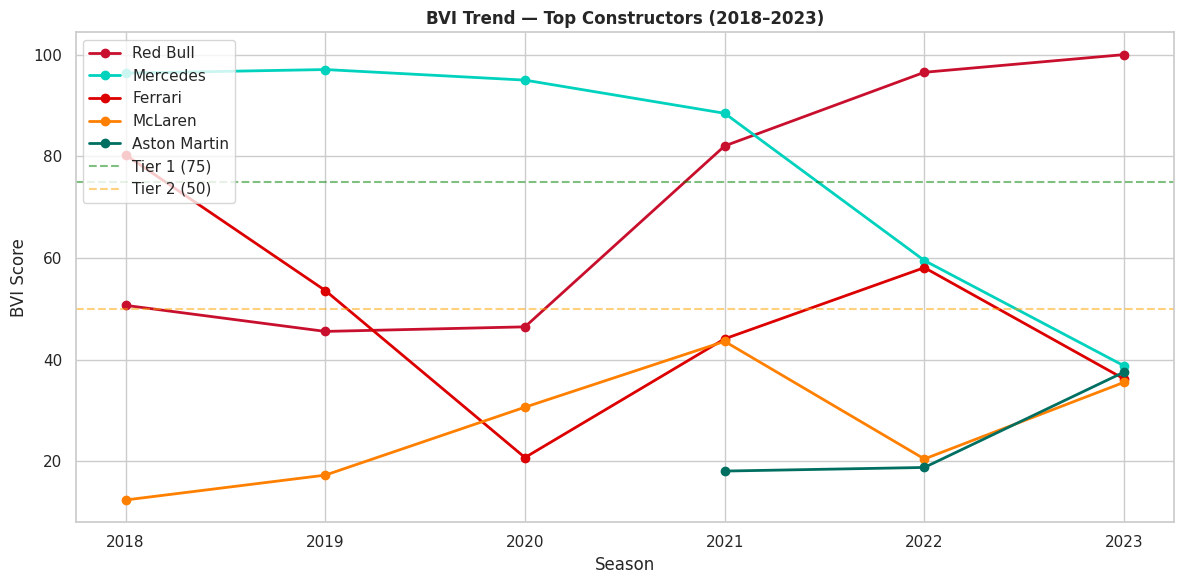

In [10]:
TOP = ['Red Bull', 'Mercedes', 'Ferrari', 'McLaren', 'Aston Martin']
COLORS = {'Red Bull':'#C8102E','Mercedes':'#00D2BE','Ferrari':'#DC0000',
          'McLaren':'#FF8000','Aston Martin':'#006F62'}

plt.figure(figsize=(12, 6))
for team in TOP:
    d = bvi[bvi['constructor'] == team].sort_values('season')
    if len(d):
        plt.plot(d['season'], d['bvi'], marker='o', linewidth=2,
                 label=team, color=COLORS.get(team, 'gray'))

plt.axhline(75, color='green', linestyle='--', alpha=0.5, label='Tier 1 (75)')
plt.axhline(50, color='orange', linestyle='--', alpha=0.5, label='Tier 2 (50)')
plt.xlabel('Season')
plt.ylabel('BVI Score')
plt.title('BVI Trend — Top Constructors (2018–2023)', fontweight='bold')
plt.legend(loc='upper left')
plt.xticks(SEASONS)
plt.tight_layout()
plt.savefig(OUT / 'bvi_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

- **Red Bull** climbed from BVI 50.7 (2018) to a perfect 100.0 (2023) — the most dramatic ascent in the dataset.
- **Mercedes** collapsed from 96.3 to 35.8 across the same window as the regulation changes bit.
- **McLaren's** 2021 BVI (43.6) exceeded their 2022 score (20.4) despite similar points — the Exposure dimension captured their high-profile late-season victory.
- Only **Tier 1** constructors (BVI ≥ 75) merit premium sponsorship pricing — typically just 1–2 teams per season.

Proceed to `03_constructor_points_model.ipynb`.